# Three Pole Opamp Response


Transfer Function: <TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                    2.481e+20
  ---------------------------------------------
  s^3 + 6.346e+07 s^2 + 3.948e+13 s + 2.481e+15

Gain Margin: 10.101
Phase Margin: 16.204 degrees
Gain Crossover Frequency: 308346.358 Hz
Phase Crossover Frequency: 1000050.499 Hz


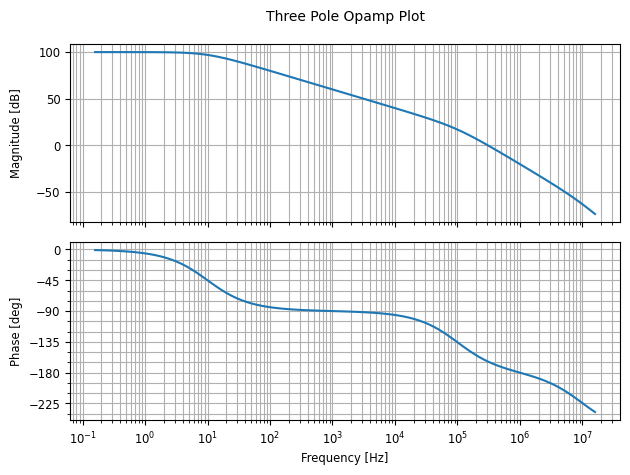

In [3]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np

pi2 = math.pi * 2.0

# pole locations
n1 = 1e5
p1 = 1.0e1
p2 = 1.0e5
p3 = 1.0e7

# 1. Define component values
s = ct.tf('s')
sys = n1 / ((1.0 +  s/(pi2 * p1)) * (1.0 + s/(pi2 * p2)) * (1.0 + s/(pi2*p3)))

gm, pm, wcg, wcp = ct.margin(sys)
fcg = wcg / (2 * math.pi)
fcp = wcp / (2 * math.pi)

print(f"\nTransfer Function: {sys}")
print(f"\nGain Margin: {gm:.3f}")
print(f"Phase Margin: {pm:.3f} degrees")
print(f"Gain Crossover Frequency: {fcp:.3f} Hz")
print(f"Phase Crossover Frequency: {fcg:.3f} Hz")

# 3. Generate the Bode plot
# This returns magnitude, phase, and frequency arrays
w = np.logspace(0,8,100)
out = ct.bode_plot(sys, w, dB=True, Hz=True, deg=True, title="Three Pole Opamp Plot")
plt.savefig("threepoleopamp-plot.pdf", format="pdf")  
plt.show()


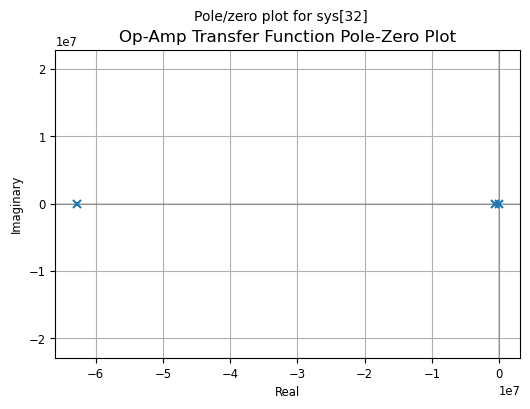

In [4]:
# 2. Plot Poles and Zeros
plt.figure(figsize=(6, 4))
ct.pole_zero_plot(sys)
plt.title('Op-Amp Transfer Function Pole-Zero Plot')
plt.grid(True)
plt.show()